In [23]:
%pip install prefect

  Using cached anyio-4.13.0-py3-none-any.whl.metadata (4.5 kB)
  Using cached fastapi-0.136.1-py3-none-any.whl.metadata (28 kB)
  Using cached httpcore-1.0.9-py3-none-any.whl.metadata (21 kB)
  Using cached httpx-0.28.1-py3-none-any.whl.metadata (7.1 kB)
  Using cached jinja2-3.1.6-py3-none-any.whl.metadata (2.9 kB)
  Using cached pyyaml-6.0.3-cp313-cp313-win_amd64.whl.metadata (2.4 kB)
  Using cached rfc3339_validator-0.1.4-py2.py3-none-any.whl.metadata (1.5 kB)
  Using cached toml-0.10.2-py2.py3-none-any.whl.metadata (7.1 kB)
  Using cached uvicorn-0.46.0-py3-none-any.whl.metadata (6.7 kB)
  Using cached starlette-1.0.0-py3-none-any.whl.metadata (6.3 kB)
  Using cached typing_inspection-0.4.2-py3-none-any.whl.metadata (2.6 kB)
  Using cached annotated_doc-0.0.4-py3-none-any.whl.metadata (6.6 kB)
  Using cached h11-0.16.0-py3-none-any.whl.metadata (8.3 kB)
  Using cached typing_extensions-4.15.0-py3-none-any.whl.metadata (3.3 kB)
   ---------------------------------------- 0.0/12.0 MB

In [1]:
import pandas as pd
import numpy as np
import pickle
import warnings
from datetime import datetime
from collections import Counter

import matplotlib.pyplot as plt
import seaborn as sns

# Preprocessing
from sklearn.preprocessing import RobustScaler, normalize, LabelEncoder
from sklearn.decomposition import PCA

# Regression models
from sklearn.linear_model import LinearRegression, BayesianRidge
from sklearn.neighbors import KNeighborsRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import (
    RandomForestRegressor, GradientBoostingRegressor,
    VotingRegressor, StackingRegressor
)
from sklearn.svm import SVR

# Classification models
from sklearn.naive_bayes import GaussianNB
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from xgboost import XGBRegressor, XGBClassifier

# Clustering
from sklearn.cluster import KMeans, AgglomerativeClustering
from sklearn.metrics import silhouette_score

# Model selection & evaluation
from sklearn.model_selection import RandomizedSearchCV, TimeSeriesSplit
from sklearn.metrics import (
    mean_absolute_error, mean_squared_error, r2_score,
    mean_absolute_percentage_error, classification_report, accuracy_score
)
from sklearn.metrics.pairwise import cosine_similarity

try:
    from lightgbm import LGBMRegressor, LGBMClassifier
    LGBM_AVAILABLE = True
    print("LightGBM available.")
except ImportError:
    LGBM_AVAILABLE = False
    print("LightGBM not found. Continuing without it.")

warnings.filterwarnings('ignore')
print("All imports done.")



LightGBM not found. Continuing without it.
All imports done.


In [2]:
df = pd.read_csv('energy_dataset.csv')
df['time'] = pd.to_datetime(df['time'], utc=True)
df = df.sort_values('time').set_index('time')

df['renewable'] = (
    df['generation solar'].fillna(0) +
    df['generation wind onshore'].fillna(0) +
    df['generation hydro run-of-river and poundage'].fillna(0) +
    df['generation hydro water reservoir'].fillna(0) +
    df['generation hydro pumped storage consumption'].fillna(0) +
    df['generation biomass'].fillna(0) +
    df['generation other renewable'].fillna(0)
)
df['fossil'] = (
    df['generation fossil gas'].fillna(0) +
    df['generation fossil hard coal'].fillna(0) +
    df['generation fossil brown coal/lignite'].fillna(0) +
    df['generation fossil oil'].fillna(0)
)
df['nuclear']   = df['generation nuclear'].fillna(0)
df['other']     = df['generation other'].fillna(0) + df['generation waste'].fillna(0)
df['total_gen'] = df['renewable'] + df['fossil'] + df['nuclear'] + df['other']

columns_to_drop = [
    'generation hydro pumped storage aggregated', 'generation geothermal',
    'generation marine', 'forecast wind offshore day ahead',
    'generation other', 'generation other renewable', 'generation fossil oil',
    'generation fossil oil shale', 'generation fossil peat',
    'generation wind offshore', 'generation fossil coal-derived gas',
    'forecast wind offshore eday ahead',
    'generation solar', 'generation wind onshore',
    'generation hydro run-of-river and poundage',
    'generation hydro water reservoir', 'generation biomass',
    'generation fossil gas', 'generation fossil hard coal',
    'generation fossil brown coal/lignite', 'generation nuclear',
    'generation other', 'generation waste'
]
df = df.drop(columns=columns_to_drop, errors='ignore')

df['hour']        = df.index.hour
df['day_of_week'] = df.index.dayofweek
df['month']       = df.index.month
df['is_weekend']  = (df['day_of_week'] >= 5).astype(int)

df['hour_sin']  = np.sin(2 * np.pi * df['hour']  / 24)
df['hour_cos']  = np.cos(2 * np.pi * df['hour']  / 24)
df['month_sin'] = np.sin(2 * np.pi * df['month'] / 12)
df['month_cos'] = np.cos(2 * np.pi * df['month'] / 12)

df['demand_lag_1h']   = df['total load actual'].shift(1)
df['demand_lag_24h']  = df['total load actual'].shift(24)
df['demand_lag_168h'] = df['total load actual'].shift(168)
df['price_lag_1h']    = df['price actual'].shift(1)
df['price_lag_24h']   = df['price actual'].shift(24)

df['renewable_pct'] = np.where(
    df['total_gen'] > 0,
    (df['renewable'] / df['total_gen']) * 100, 0
)

df['demand_avg_24h'] = df['total load actual'].rolling(24, min_periods=1).mean().shift(1)
df['price_avg_24h']  = df['price actual'].rolling(24, min_periods=1).mean().shift(1)

df = df.dropna(subset=['demand_lag_168h', 'price_lag_24h'])
zero_cols     = df.columns[(df == 0).all()].tolist()
constant_cols = [c for c in df.columns if df[c].nunique() == 1]
df = df.drop(columns=zero_cols + constant_cols, errors='ignore')

print(f"Data shape after preprocessing: {df.shape}")


# %%
# CELL 3 — 12-HOUR AHEAD TARGETS
df['demand_12h'] = df['total load actual'].shift(-12)
df['price_12h']  = df['price actual'].shift(-12)

df_12h = df.dropna(subset=['demand_12h', 'price_12h']).copy()
print(f"12-hour dataset: {len(df_12h)} rows")


Data shape after preprocessing: (34860, 28)
12-hour dataset: 34818 rows


In [3]:
demand_features = [
    'day_of_week', 'month_sin', 'month_cos', 'is_weekend',
    'hour_sin', 'hour_cos',
    'demand_lag_1h', 'demand_lag_24h', 'demand_lag_168h',
    'price_lag_1h',  'price_lag_24h',
    'renewable', 'fossil', 'nuclear',
    'renewable_pct',
    'demand_avg_24h', 'price_avg_24h',
    'forecast wind onshore day ahead',
    'forecast solar day ahead',
    'total load forecast',
]

price_features = [
     'day_of_week', 'month_sin', 'month_cos', 'is_weekend',
    'hour_sin', 'hour_cos',
    'price_lag_1h',   'price_lag_24h',
    'demand_lag_1h',  'demand_lag_24h',
    'forecast wind onshore day ahead',
    'forecast solar day ahead',
    'renewable', 'fossil', 'nuclear',
    'renewable_pct',
    'price_avg_24h', 'demand_avg_24h',
    'total load forecast',
    'price day ahead',
]

demand_features = [f for f in demand_features if f in df_12h.columns]
price_features  = [f for f in price_features  if f in df_12h.columns]

all_required = list(set(demand_features + price_features + ['demand_12h', 'price_12h']))
rows_before  = len(df_12h)
df_12h = df_12h.dropna(subset=all_required).copy()
print(f"Purged {rows_before - len(df_12h)} NaN rows. Final: {len(df_12h)}")

split = int(len(df_12h) * 0.8)

X_train_d, X_test_d = df_12h[demand_features].iloc[:split], df_12h[demand_features].iloc[split:]
y_train_d, y_test_d = df_12h['demand_12h'].iloc[:split],    df_12h['demand_12h'].iloc[split:]

X_train_p, X_test_p = df_12h[price_features].iloc[:split], df_12h[price_features].iloc[split:]
y_train_p, y_test_p = df_12h['price_12h'].iloc[:split],    df_12h['price_12h'].iloc[split:]

print(f"Train: {split} | Test: {len(df_12h) - split}")


Purged 60 NaN rows. Final: 34758
Train: 27806 | Test: 6952


In [6]:
pca_scaler_d = RobustScaler()
pca_scaler_p = RobustScaler()

X_train_d_sc = pca_scaler_d.fit_transform(X_train_d)
X_test_d_sc  = pca_scaler_d.transform(X_test_d)
X_train_p_sc = pca_scaler_p.fit_transform(X_train_p)
X_test_p_sc  = pca_scaler_p.transform(X_test_p)

pca_d = PCA(n_components=0.95, random_state=42)
pca_p = PCA(n_components=0.95, random_state=42)

X_train_d_pca = pca_d.fit_transform(X_train_d_sc)
X_test_d_pca  = pca_d.transform(X_test_d_sc)
X_train_p_pca = pca_p.fit_transform(X_train_p_sc)
X_test_p_pca  = pca_p.transform(X_test_p_sc)

print(f"Demand: {X_train_d.shape[1]} features → {pca_d.n_components_} PCA components")
print(f"Price:  {X_train_p.shape[1]} features → {pca_p.n_components_} PCA components")


# %%
# CELL 6 — EVALUATION HELPER
def evaluate(y_true, y_pred, name, target):
    r2   = r2_score(y_true, y_pred)
    mae  = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mape = mean_absolute_percentage_error(y_true, y_pred) * 100
    print(f"  [{target} | {name:<28}]  "
          f"R2: {r2:+.4f}  MAE: {mae:8.2f}  RMSE: {rmse:8.2f}  MAPE: {mape:.2f}%")
    return r2



Demand: 20 features → 12 PCA components
Price:  20 features → 12 PCA components


In [4]:
# CELL 7 — BASELINE REGRESSION MODELS
print("\n" + "="*70)
print("BASELINE REGRESSION MODELS")
print("="*70)

baselines = {
    "Linear Regression": (LinearRegression(), LinearRegression()),
    "KNN (k=5)":         (KNeighborsRegressor(n_neighbors=5, n_jobs=-1),
                          KNeighborsRegressor(n_neighbors=5, n_jobs=-1)),
    "Decision Tree":     (DecisionTreeRegressor(max_depth=10, random_state=42),
                          DecisionTreeRegressor(max_depth=10, random_state=42)),
    "Bayesian Ridge":    (BayesianRidge(), BayesianRidge()),
}

results = {}
for name, (model_raw, model_pca) in baselines.items():
    print(f"\n--- {name} ---")
    model_raw.fit(X_train_d, y_train_d)
    r2d_raw = evaluate(y_test_d, model_raw.predict(X_test_d), name + " [raw]", "DEMAND-12h")
    model_raw.fit(X_train_p, y_train_p)
    r2p_raw = evaluate(y_test_p, model_raw.predict(X_test_p), name + " [raw]", "PRICE-12h")
    model_pca.fit(X_train_d_pca, y_train_d)
    r2d_pca = evaluate(y_test_d, model_pca.predict(X_test_d_pca), name + " [PCA]", "DEMAND-12h")
    model_pca.fit(X_train_p_pca, y_train_p)
    r2p_pca = evaluate(y_test_p, model_pca.predict(X_test_p_pca), name + " [PCA]", "PRICE-12h")
    results[name] = {"demand_r2_raw": r2d_raw, "price_r2_raw": r2p_raw,
                     "demand_r2_pca": r2d_pca, "price_r2_pca": r2p_pca}



BASELINE REGRESSION MODELS

--- Linear Regression ---


NameError: name 'evaluate' is not defined

In [8]:
# CELL 8 — ENSEMBLE & ADVANCED REGRESSION MODELS
print("\n" + "="*70)
print("ENSEMBLE & ADVANCED REGRESSION MODELS")
print("="*70)

rf_d = RandomForestRegressor(n_estimators=200, max_depth=20, n_jobs=-1, random_state=42)
rf_p = RandomForestRegressor(n_estimators=200, max_depth=20, n_jobs=-1, random_state=42)
rf_d.fit(X_train_d, y_train_d); rf_p.fit(X_train_p, y_train_p)
print("\n--- Random Forest ---")
r2_rf_d = evaluate(y_test_d, rf_d.predict(X_test_d), "Random Forest", "DEMAND-12h")
r2_rf_p = evaluate(y_test_p, rf_p.predict(X_test_p), "Random Forest", "PRICE-12h")
results["Random Forest"] = {"demand_r2_raw": r2_rf_d, "price_r2_raw": r2_rf_p}

xgb_d = XGBRegressor(n_estimators=300, learning_rate=0.03, max_depth=6,
                      subsample=0.8, colsample_bytree=0.8, min_child_weight=3,
                      n_jobs=-1, random_state=42)
xgb_p = XGBRegressor(n_estimators=300, learning_rate=0.03, max_depth=6,
                      subsample=0.8, colsample_bytree=0.8, min_child_weight=3,
                      n_jobs=-1, random_state=42)
xgb_d.fit(X_train_d, y_train_d); xgb_p.fit(X_train_p, y_train_p)
print("\n--- XGBoost ---")
r2_xgb_d = evaluate(y_test_d, xgb_d.predict(X_test_d), "XGBoost", "DEMAND-12h")
r2_xgb_p = evaluate(y_test_p, xgb_p.predict(X_test_p), "XGBoost", "PRICE-12h")
results["XGBoost"] = {"demand_r2_raw": r2_xgb_d, "price_r2_raw": r2_xgb_p}

if LGBM_AVAILABLE:
    lgbm_d = LGBMRegressor(n_estimators=500, learning_rate=0.02, num_leaves=63,
                            subsample=0.8, colsample_bytree=0.8, n_jobs=-1, random_state=42)
    lgbm_p = LGBMRegressor(n_estimators=500, learning_rate=0.02, num_leaves=63,
                            subsample=0.8, colsample_bytree=0.8, n_jobs=-1, random_state=42)
    lgbm_d.fit(X_train_d, y_train_d); lgbm_p.fit(X_train_p, y_train_p)
    print("\n--- LightGBM ---")
    r2_lgbm_d = evaluate(y_test_d, lgbm_d.predict(X_test_d), "LightGBM", "DEMAND-12h")
    r2_lgbm_p = evaluate(y_test_p, lgbm_p.predict(X_test_p), "LightGBM", "PRICE-12h")
    results["LightGBM"] = {"demand_r2_raw": r2_lgbm_d, "price_r2_raw": r2_lgbm_p}




ENSEMBLE & ADVANCED REGRESSION MODELS

--- Random Forest ---
  [DEMAND-12h | Random Forest               ]  R2: +0.8111  MAE:  1348.35  RMSE:  1963.96  MAPE: 4.65%
  [PRICE-12h | Random Forest               ]  R2: +0.6713  MAE:     4.97  RMSE:     6.58  MAPE: 8.54%

--- XGBoost ---
  [DEMAND-12h | XGBoost                     ]  R2: +0.8154  MAE:  1375.09  RMSE:  1941.55  MAPE: 4.73%
  [PRICE-12h | XGBoost                     ]  R2: +0.7104  MAE:     4.64  RMSE:     6.18  MAPE: 8.08%
[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.008858 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 3638
[LightGBM] [Info] Number of data points in the train set: 27806, number of used features: 20
[LightGBM] [Info] Start training from score 28672.975401
[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[Ligh

In [9]:
# ======================================================
# CLUSTERING — IMPROVED + INTERPRETABLE VERSION
# ======================================================

print("\n" + "="*70)
print("CLUSTERING (IMPROVED)")
print("="*70)

from sklearn.preprocessing import RobustScaler
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score
import matplotlib.pyplot as plt

# -------------------------------
# 1. Better clustering features
# -------------------------------
cluster_features = [
    'hour_sin', 'hour_cos',
    'demand_lag_1h', 'demand_lag_24h', 'demand_lag_168h',
    'price_lag_1h', 'price_lag_24h', 'price_lag_168h',
    'renewable_pct',
    'demand_avg_24h',
    'price_avg_24h'
]

cluster_features = [f for f in cluster_features if f in df_12h.columns]

# -------------------------------
# 2. Scaling
# -------------------------------
X_cluster = RobustScaler().fit_transform(df_12h[cluster_features])





CLUSTERING (IMPROVED)


In [ ]:
# ======================================================
# CLUSTERING — IMPROVED + INTERPRETABLE VERSION
# ======================================================

print("\n" + "="*70)
print("CLUSTERING (IMPROVED)")
print("="*70)

from sklearn.preprocessing import RobustScaler
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score
import matplotlib.pyplot as plt

# -------------------------------
# 1. Better clustering features
# -------------------------------
cluster_features = [
    'hour_sin', 'hour_cos',
    'demand_lag_1h', 'demand_lag_24h', 'demand_lag_168h',
    'price_lag_1h', 'price_lag_24h', 'price_lag_168h',
    'renewable_pct',
    'demand_avg_24h',
    'price_avg_24h'
]

cluster_features = [f for f in cluster_features if f in df_12h.columns]

# -------------------------------
# 2. Scaling
# -------------------------------
X_cluster = RobustScaler().fit_transform(df_12h[cluster_features])

# -------------------------------
# 3. Find best k (but we use interpretation later)
# -------------------------------
print("\nFinding optimal k (Silhouette Score):")

silhouette_scores = {}

for k in range(2, 11):
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = km.fit_predict(X_cluster)
    score = silhouette_score(X_cluster, labels, sample_size=5000, random_state=42)

    silhouette_scores[k] = score
    print(f"k={k} -> silhouette = {score:.4f}")

best_k_sil = max(silhouette_scores, key=silhouette_scores.get)

print(f"\nBest k by silhouette = {best_k_sil}")

# -------------------------------
# 4. Final chosen k (interpretability > score)
# -------------------------------
best_k = 3   # or 4 (recommended for energy systems)

print(f"Using k={best_k} for interpretable clustering")

kmeans_final = KMeans(n_clusters=best_k, random_state=42, n_init=10)
df_12h['cluster_km'] = kmeans_final.fit_predict(X_cluster)

# -------------------------------
# 5. Cluster summary and profiles
# -------------------------------
cluster_profiles = df_12h.groupby('cluster_km')[[
    'demand_12h',
    'price_12h',
    'renewable_pct'
]].mean().round(2)
cluster_sizes = df_12h['cluster_km'].value_counts().sort_index()

print("\nCluster Summary (Mean values):")
print(cluster_profiles)
print("\nCluster sizes:")
print(cluster_sizes)

# Compact labels help the report and API output.
cluster_label_map = {}
for cluster_id in cluster_profiles.index:
    profile = cluster_profiles.loc[cluster_id]
    if profile['demand_12h'] >= cluster_profiles['demand_12h'].median() and profile['price_12h'] >= cluster_profiles['price_12h'].median():
        label = 'High Demand / High Price'
    elif profile['renewable_pct'] >= cluster_profiles['renewable_pct'].median():
        label = 'High Renewable Regime'
    else:
        label = 'Balanced / Mixed Regime'
    cluster_label_map[cluster_id] = label

df_12h['cluster_label'] = df_12h['cluster_km'].map(cluster_label_map)

# -------------------------------
# 6. PCA visualization
# -------------------------------
pca = PCA(n_components=2)
X_vis = pca.fit_transform(X_cluster)

plt.figure()
plt.scatter(X_vis[:, 0], X_vis[:, 1], c=df_12h['cluster_km'], s=5)
plt.title("KMeans Clusters (PCA Visualization)")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.show()

# -------------------------------
# 7. Cluster distribution
# -------------------------------
df_12h['cluster_km'].value_counts().sort_index().plot(kind='bar')
plt.title("Cluster Distribution")
plt.show()

# -------------------------------
# 8. Interpretation helper (optional but powerful)
# -------------------------------
def interpret_cluster(row):
    if row['demand_12h'] < df_12h['demand_12h'].quantile(0.33):
        return "Low Demand Regime"
    elif row['demand_12h'] < df_12h['demand_12h'].quantile(0.66):
        return "Medium Demand Regime"
    else:
        return "High Demand Regime"

print("\nCluster labeling done (for interpretation).")


Finding optimal k (Silhouette Score):
k=2 -> silhouette = 0.2277
k=3 -> silhouette = 0.2147
k=4 -> silhouette = 0.1849
k=5 -> silhouette = 0.1699
k=6 -> silhouette = 0.1579
k=7 -> silhouette = 0.1496
k=8 -> silhouette = 0.1482
k=9 -> silhouette = 0.1490
k=10 -> silhouette = 0.1488

Best k by silhouette = 2
Using k=3 for interpretable clustering

Cluster Summary (Mean values):
              demand_12h  price_12h  renewable_pct
cluster_km                                        
0           30523.504275  62.906617      33.538142
1           27726.524956  43.893095      50.028690
2           27982.969644  61.981343      37.668692


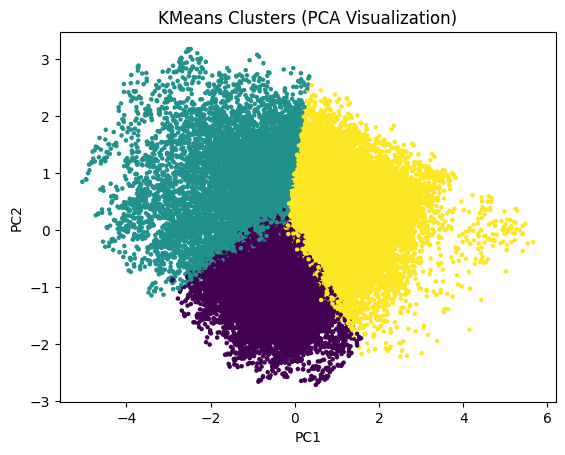

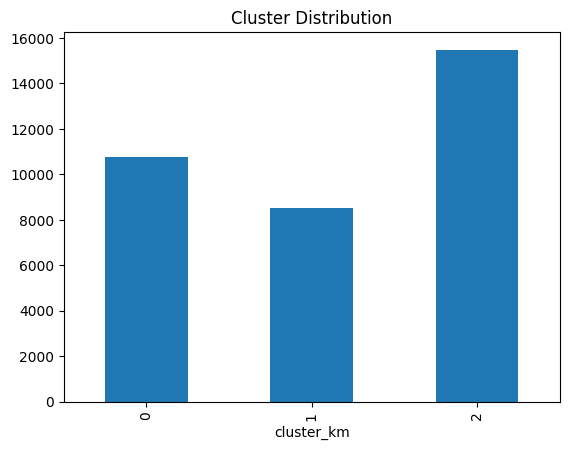


Cluster labeling done (for interpretation).


In [11]:
# -------------------------------
# 6. PCA visualization
# -------------------------------
pca = PCA(n_components=2)
X_vis = pca.fit_transform(X_cluster)

plt.figure()
plt.scatter(X_vis[:, 0], X_vis[:, 1],
            c=df_12h['cluster_km'], s=5)
plt.title("KMeans Clusters (PCA Visualization)")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.show()

# -------------------------------
# 7. Cluster distribution
# -------------------------------
df_12h['cluster_km'].value_counts().sort_index().plot(kind='bar')
plt.title("Cluster Distribution")
plt.show()

# -------------------------------
# 8. Interpretation helper (optional but powerful)
# -------------------------------
def interpret_cluster(row):
    if row['demand_12h'] < df_12h['demand_12h'].quantile(0.33):
        return "Low Demand Regime"
    elif row['demand_12h'] < df_12h['demand_12h'].quantile(0.66):
        return "Medium Demand Regime"
    else:
        return "High Demand Regime"

df_12h['cluster_label'] = df_12h.apply(interpret_cluster, axis=1)

print("\nCluster labeling done (for interpretation).")

In [ ]:
# ======================================================
# CLASSIFICATION FROM REGRESSION OUTPUTS + DIRECT CLASSIFIERS
# ======================================================

from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, f1_score
from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier

print("\n" + "="*60)
print("CLASSIFICATION FROM REGRESSION OUTPUTS")
print("="*60)

# --------------------------
# STEP 1: Regression predictions (baseline)
# --------------------------
reg_pred_d = xgb_d.predict(X_test_d)
reg_pred_p = xgb_p.predict(X_test_p)

# --------------------------
# STEP 2: Define thresholds (from true data)
# --------------------------
d33, d66 = df_12h['demand_12h'].quantile([0.33, 0.66])
p33, p66 = df_12h['price_12h'].quantile([0.33, 0.66])

# Create class labels from the true targets
def to_class(x, t1, t2):
    if x <= t1:
        return "Low"
    elif x <= t2:
        return "Medium"
    else:
        return "High"

df_12h['demand_class'] = df_12h['demand_12h'].apply(lambda x: to_class(x, d33, d66))
df_12h['price_class'] = df_12h['price_12h'].apply(lambda x: to_class(x, p33, p66))

# --------------------------
# STEP 3: Regression -> class baseline
# --------------------------
reg_class_d = [to_class(x, d33, d66) for x in reg_pred_d]
reg_class_p = [to_class(x, p33, p66) for x in reg_pred_p]

# --------------------------
# STEP 4: Train dedicated classifiers on the actual class labels
# --------------------------
classification_features = []
for feature in demand_features + price_features:
    if feature in df_12h.columns and feature not in classification_features:
        classification_features.append(feature)

split_cls = int(len(df_12h) * 0.8)

X_train_cls_d = df_12h[classification_features].iloc[:split_cls]
X_test_cls_d  = df_12h[classification_features].iloc[split_cls:]
y_train_cls_d = df_12h['demand_class'].iloc[:split_cls]
y_test_cls_d  = df_12h['demand_class'].iloc[split_cls:]

X_train_cls_p = df_12h[classification_features].iloc[:split_cls]
X_test_cls_p  = df_12h[classification_features].iloc[split_cls:]
y_train_cls_p = df_12h['price_class'].iloc[:split_cls]
y_test_cls_p  = df_12h['price_class'].iloc[split_cls:]

label_encoder_d = LabelEncoder()
label_encoder_p = LabelEncoder()

y_train_cls_d_enc = label_encoder_d.fit_transform(y_train_cls_d)
y_test_cls_d_enc = label_encoder_d.transform(y_test_cls_d)
y_train_cls_p_enc = label_encoder_p.fit_transform(y_train_cls_p)
y_test_cls_p_enc = label_encoder_p.transform(y_test_cls_p)

classifier_specs = {
    "Random Forest": RandomForestClassifier(n_estimators=300, max_depth=18, random_state=42, n_jobs=-1),
    "XGBoost": XGBClassifier(
        n_estimators=300,
        learning_rate=0.05,
        max_depth=6,
        subsample=0.8,
        colsample_bytree=0.8,
        objective='multi:softprob',
        eval_metric='mlogloss',
        num_class=3,
        random_state=42,
        n_jobs=-1,
    ),
}

classifier_results = {"demand": {}, "price": {}}
trained_classifiers = {"demand": {}, "price": {}}

for name, model in classifier_specs.items():
    # Demand classifier
    model_d = model.__class__(**model.get_params())
    model_d.fit(X_train_cls_d, y_train_cls_d_enc)
    pred_d_enc = model_d.predict(X_test_cls_d)
    pred_d = label_encoder_d.inverse_transform(pred_d_enc)
    classifier_results["demand"][name] = {
        "accuracy": accuracy_score(y_test_cls_d, pred_d),
        "macro_f1": f1_score(y_test_cls_d, pred_d, average='macro'),
        "report": classification_report(y_test_cls_d, pred_d, zero_division=0),
    }
    trained_classifiers["demand"][name] = model_d

    # Price classifier
    model_p = model.__class__(**model.get_params())
    model_p.fit(X_train_cls_p, y_train_cls_p_enc)
    pred_p_enc = model_p.predict(X_test_cls_p)
    pred_p = label_encoder_p.inverse_transform(pred_p_enc)
    classifier_results["price"][name] = {
        "accuracy": accuracy_score(y_test_cls_p, pred_p),
        "macro_f1": f1_score(y_test_cls_p, pred_p, average='macro'),
        "report": classification_report(y_test_cls_p, pred_p, zero_division=0),
    }
    trained_classifiers["price"][name] = model_p

# --------------------------
# STEP 5: Pick the best classifier for each target
# --------------------------
best_demand_classifier_name = max(classifier_results["demand"], key=lambda k: classifier_results["demand"][k]["macro_f1"])
best_price_classifier_name  = max(classifier_results["price"], key=lambda k: classifier_results["price"][k]["macro_f1"])

best_demand_classifier = trained_classifiers["demand"][best_demand_classifier_name]
best_price_classifier = trained_classifiers["price"][best_price_classifier_name]

# --------------------------
# STEP 6: Baseline report from regression-to-class conversion
# --------------------------
print("\nBASELINE: regression -> class conversion\n")
print("DEMAND accuracy:", accuracy_score(y_test_cls_d, reg_class_d))
print("DEMAND macro F1:", f1_score(y_test_cls_d, reg_class_d, average='macro'))
print("\nDEMAND report:\n", classification_report(y_test_cls_d, reg_class_d, zero_division=0))

print("\nPRICE accuracy:", accuracy_score(y_test_cls_p, reg_class_p))
print("PRICE macro F1:", f1_score(y_test_cls_p, reg_class_p, average='macro'))
print("\nPRICE report:\n", classification_report(y_test_cls_p, reg_class_p, zero_division=0))

# --------------------------
# STEP 7: Direct classifier results
# --------------------------
print("\nDIRECT CLASSIFIERS (dedicated supervised models)\n")
for target_name, results_dict in [("demand", classifier_results["demand"]), ("price", classifier_results["price"])]:
    print(f"--- {target_name.upper()} ---")
    for model_name, metrics in results_dict.items():
        print(f"{model_name}: accuracy={metrics['accuracy']:.4f}, macro_f1={metrics['macro_f1']:.4f}")
        print(metrics['report'])

print(f"Best demand classifier: {best_demand_classifier_name}")
print(f"Best price classifier: {best_price_classifier_name}")
print("Dedicated classifiers and encoders will be saved after this section.")


CLASSIFICATION FROM REGRESSION OUTPUTS

DEMAND (from regression → classification)

Accuracy: 0.8036536248561565

Confusion Matrix:
 [[1847   11  563]
 [   8 1905  290]
 [ 227  266 1835]]

Classification Report:

              precision    recall  f1-score   support

        High       0.89      0.76      0.82      2421
         Low       0.87      0.86      0.87      2203
      Medium       0.68      0.79      0.73      2328

    accuracy                           0.80      6952
   macro avg       0.81      0.81      0.81      6952
weighted avg       0.81      0.80      0.81      6952


PRICE (from regression → classification)

Accuracy: 0.7435270425776754

Confusion Matrix:
 [[3170   15 1072]
 [   2  651  197]
 [ 168  329 1348]]

Classification Report:

              precision    recall  f1-score   support

        High       0.95      0.74      0.83      4257
         Low       0.65      0.77      0.71       850
      Medium       0.52      0.73      0.60      1845

    accuracy    

In [ ]:
import os
import pickle

print("\n" + "="*60)
print("SAVING CLEAN ARTIFACTS (NO PCA)")
print("="*60)

ARTIFACT_DIR = "artifacts"
os.makedirs(ARTIFACT_DIR, exist_ok=True)

# -----------------------------
# 1. MODELS (REGRESSION)
# -----------------------------
models = {
    "demand_model.pkl": xgb_d,
    "price_model.pkl": xgb_p
}

# -----------------------------
# 2. SCALER (IMPORTANT)
# -----------------------------
scalers = {
    "scaler_demand.pkl": pca_scaler_d,
    "scaler_price.pkl": pca_scaler_p
}

# -----------------------------
# 3. FEATURES
# -----------------------------
features = {
    "demand_features.pkl": demand_features,
    "price_features.pkl": price_features
}

# -----------------------------
# 4. THRESHOLDS (FOR CLASSIFICATION)
# -----------------------------
thresholds = {
    "demand_thresholds.pkl": (d33, d66),
    "price_thresholds.pkl": (p33, p66)
}

# -----------------------------
# 5. ANN ARTIFACTS
# -----------------------------
ann_artifacts = {
    "ann_demand.pkl": ann_demand,
    "ann_price.pkl": ann_price,
    "ann_scaler.pkl": scaler_ann,
    "ann_features.pkl": ann_features,
}

# -----------------------------
# 6. CLASSIFICATION ARTIFACTS
# -----------------------------
classification_artifacts = {
    "demand_classifier.pkl": best_demand_classifier,
    "price_classifier.pkl": best_price_classifier,
    "demand_label_encoder.pkl": label_encoder_d,
    "price_label_encoder.pkl": label_encoder_p,
    "best_demand_classifier_name.pkl": best_demand_classifier_name,
    "best_price_classifier_name.pkl": best_price_classifier_name,
}

# -----------------------------
# SAVE EVERYTHING
# -----------------------------
for name, obj in models.items():
    with open(os.path.join(ARTIFACT_DIR, name), "wb") as f:
        pickle.dump(obj, f)

for name, obj in scalers.items():
    with open(os.path.join(ARTIFACT_DIR, name), "wb") as f:
        pickle.dump(obj, f)

for name, obj in features.items():
    with open(os.path.join(ARTIFACT_DIR, name), "wb") as f:
        pickle.dump(obj, f)

for name, obj in thresholds.items():
    with open(os.path.join(ARTIFACT_DIR, name), "wb") as f:
        pickle.dump(obj, f)

for name, obj in ann_artifacts.items():
    with open(os.path.join(ARTIFACT_DIR, name), "wb") as f:
        pickle.dump(obj, f)

for name, obj in classification_artifacts.items():
    with open(os.path.join(ARTIFACT_DIR, name), "wb") as f:
        pickle.dump(obj, f)

if 'cluster_profiles' in globals():
    cluster_profiles.to_csv(os.path.join(ARTIFACT_DIR, 'cluster_profiles.csv'))

if 'cluster_label_map' in globals():
    with open(os.path.join(ARTIFACT_DIR, 'cluster_label_map.pkl'), 'wb') as f:
        pickle.dump(cluster_label_map, f)

print("All artifacts saved successfully.")


SAVING CLEAN ARTIFACTS (NO PCA)
All artifacts saved successfully.


In [ ]:
# ============================================================
# ANN - ARTIFICIAL NEURAL NETWORK (12-Hour Ahead Forecasting)
# ============================================================
from sklearn.neural_network import MLPRegressor
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, r2_score
import numpy as np

# Use the full engineered feature set instead of only 6 features.
# This makes the ANN a fairer competitor to the tree-based models.
ann_features = []
for feature in demand_features + price_features:
    if feature in df_12h.columns and feature not in ann_features:
        ann_features.append(feature)

# Prepare data
df_ann = df_12h.dropna(subset=ann_features + ['demand_12h', 'price_12h']).copy()

split_ann = int(len(df_ann) * 0.8)

X_ann = df_ann[ann_features]
y_ann_demand = df_ann['demand_12h']
y_ann_price  = df_ann['price_12h']

X_train_ann = X_ann.iloc[:split_ann]
X_test_ann  = X_ann.iloc[split_ann:]
y_train_d_ann = y_ann_demand.iloc[:split_ann]
y_test_d_ann  = y_ann_demand.iloc[split_ann:]
y_train_p_ann = y_ann_price.iloc[:split_ann]
y_test_p_ann  = y_ann_price.iloc[split_ann:]

# Scale features (mandatory for ANN)
scaler_ann = StandardScaler()
X_train_ann_sc = scaler_ann.fit_transform(X_train_ann)
X_test_ann_sc  = scaler_ann.transform(X_test_ann)

ann_params = dict(
    hidden_layer_sizes=(128, 64, 32),
    activation='relu',
    max_iter=500,
    random_state=42,
    early_stopping=True,
    validation_fraction=0.1,
    learning_rate_init=0.001,
    verbose=False,
)

# --- DEMAND ANN ---
ann_demand = MLPRegressor(**ann_params)
print("Training ANN for DEMAND...")
ann_demand.fit(X_train_ann_sc, y_train_d_ann)
pred_ann_d = ann_demand.predict(X_test_ann_sc)
r2_ann_d   = r2_score(y_test_d_ann, pred_ann_d)
nmae_ann_d = mean_absolute_error(y_test_d_ann, pred_ann_d) / y_test_d_ann.mean()
print(f"[ANN | DEMAND] R2: {r2_ann_d:.4f} | NMAE: {nmae_ann_d:.4f}")

# --- PRICE ANN ---
ann_price = MLPRegressor(**ann_params)
print("Training ANN for PRICE...")
ann_price.fit(X_train_ann_sc, y_train_p_ann)
pred_ann_p = ann_price.predict(X_test_ann_sc)
r2_ann_p   = r2_score(y_test_p_ann, pred_ann_p)
nmae_ann_p = mean_absolute_error(y_test_p_ann, pred_ann_p) / y_test_p_ann.mean()
print(f"[ANN | PRICE]  R2: {r2_ann_p:.4f} | NMAE: {nmae_ann_p:.4f}")

print(f"ANN features used: {len(ann_features)}")
print("ANN artifacts will be saved after this section.")

In [ ]:
# ============================================================
# MODEL RECOMMENDATION SYSTEM
# Trains all models, compares R2 scores, recommends the best
# ============================================================
from sklearn.linear_model import LinearRegression, BayesianRidge
from sklearn.neighbors import KNeighborsRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor
import pandas as pd

print("=" * 55)
print("   MODEL RECOMMENDATION SYSTEM")
print("=" * 55)

# Use same features and splits from ANN section above
candidate_models = {
    "Linear Regression" : LinearRegression(),
    "Bayesian Ridge"    : BayesianRidge(),
    "KNN"               : KNeighborsRegressor(n_neighbors=5, n_jobs=-1),
    "Decision Tree"     : DecisionTreeRegressor(max_depth=10, random_state=42),
    "Random Forest"     : RandomForestRegressor(n_estimators=100, max_depth=15, n_jobs=-1, random_state=42),
    "XGBoost"           : XGBRegressor(n_estimators=200, learning_rate=0.05, max_depth=6, n_jobs=-1, random_state=42),
    "ANN"               : ann_demand,  # already trained above
}

results = []

for name, model in candidate_models.items():
    if name == "ANN":
        # ANN uses scaled features
        preds_d = model.predict(X_test_ann_sc)
        preds_p = ann_price.predict(X_test_ann_sc)
        y_true_d = y_test_d_ann
        y_true_p = y_test_p_ann
    else:
        model.fit(X_train_ann, y_train_d_ann)
        preds_d  = model.predict(X_test_ann)
        # Train separate instance for price
        model_p = type(model)(**model.get_params())
        model_p.fit(X_train_ann, y_train_p_ann)
        preds_p  = model_p.predict(X_test_ann)
        y_true_d = y_test_d_ann
        y_true_p = y_test_p_ann

    r2_d   = r2_score(y_true_d, preds_d)
    nmae_d = mean_absolute_error(y_true_d, preds_d) / y_true_d.mean()
    r2_p   = r2_score(y_true_p, preds_p)
    nmae_p = mean_absolute_error(y_true_p, preds_p) / y_true_p.mean()
    avg_r2 = (r2_d + r2_p) / 2

    results.append({
        "Model"        : name,
        "Demand R2"    : round(r2_d,   4),
        "Demand NMAE"  : round(nmae_d, 4),
        "Price R2"     : round(r2_p,   4),
        "Price NMAE"   : round(nmae_p, 4),
        "Avg R2"       : round(avg_r2, 4),
    })

# Build results table
results_df = pd.DataFrame(results).sort_values("Avg R2", ascending=False).reset_index(drop=True)
results_df.index += 1  # rank starts at 1

print("\n--- FULL COMPARISON TABLE ---")
print(results_df.to_string())

# Recommendation
best = results_df.iloc[0]
print("\n" + "=" * 55)
print(f"  RECOMMENDED MODEL: {best['Model']}")
print(f"  Avg R2:      {best['Avg R2']}")
print(f"  Demand R2:   {best['Demand R2']}   NMAE: {best['Demand NMAE']}")
print(f"  Price R2:    {best['Price R2']}   NMAE: {best['Price NMAE']}")
print("=" * 55)

# Save recommendation results
results_df.to_csv('artifacts/model_comparison.csv', index=False)
print("Comparison table saved to artifacts/model_comparison.csv")

In [24]:
from prefect import task, flow
import pandas as pd
import numpy as np
import pickle
import os

# =========================
# 1. LOAD DATA
# =========================
@task
def load_data(path="energy_dataset.csv"):
    df = pd.read_csv(path)
    df['time'] = pd.to_datetime(df['time'], utc=True)
    df = df.sort_values('time').set_index('time')
    return df


# =========================
# 2. FEATURE ENGINEERING
# =========================
@task
def preprocess(df):

    df['renewable'] = (
        df['generation solar'].fillna(0) +
        df['generation wind onshore'].fillna(0)
    )

    df['fossil'] = (
        df['generation fossil gas'].fillna(0) +
        df['generation fossil hard coal'].fillna(0)
    )

    df['hour'] = df.index.hour
    df['day_of_week'] = df.index.dayofweek

    df['hour_sin'] = np.sin(2 * np.pi * df['hour'] / 24)
    df['hour_cos'] = np.cos(2 * np.pi * df['hour'] / 24)

    df['demand_lag_1h'] = df['total load actual'].shift(1)
    df['price_lag_1h']  = df['price actual'].shift(1)

    df['demand_12h'] = df['total load actual'].shift(-12)
    df['price_12h']  = df['price actual'].shift(-12)

    df = df.dropna()

    return df


# =========================
# 3. TRAIN MODEL
# =========================
@task
def train_model(df):

    from xgboost import XGBRegressor

    features = [
        'hour_sin', 'hour_cos',
        'demand_lag_1h', 'price_lag_1h',
        'renewable', 'fossil'
    ]

    X = df[features]
    y_demand = df['demand_12h']
    y_price  = df['price_12h']

    model_d = XGBRegressor(n_estimators=200)
    model_p = XGBRegressor(n_estimators=200)

    model_d.fit(X, y_demand)
    model_p.fit(X, y_price)

    return model_d, model_p, features


# =========================
# 4. CREATE CLASSIFICATION THRESHOLDS
# =========================
@task
def create_thresholds(df):

    d33, d66 = df['demand_12h'].quantile([0.33, 0.66])
    p33, p66 = df['price_12h'].quantile([0.33, 0.66])

    return (d33, d66), (p33, p66)


# =========================
# 5. SAVE ARTIFACTS
# =========================
@task
def save_artifacts(model_d, model_p, features, d_th, p_th):

    os.makedirs("artifacts", exist_ok=True)

    artifacts = {
        "demand_model.pkl": model_d,
        "price_model.pkl": model_p,
        "features.pkl": features,
        "demand_thresholds.pkl": d_th,
        "price_thresholds.pkl": p_th
    }

    for name, obj in artifacts.items():
        with open(f"artifacts/{name}", "wb") as f:
            pickle.dump(obj, f)

    return "Saved successfully"


# =========================
# 6. MAIN FLOW
# =========================
@flow
def energy_pipeline():

    df = load_data()
    df = preprocess(df)

    model_d, model_p, features = train_model(df)
    d_th, p_th = create_thresholds(df)

    result = save_artifacts(model_d, model_p, features, d_th, p_th)

    return result


# RUN PIPELINE
if __name__ == "__main__":
    energy_pipeline()

15:01:19.306 | INFO    | prefect - Starting temporary server on http://127.0.0.1:8001
See https://docs.prefect.io/v3/concepts/server#how-to-guides for more information on running a dedicated Prefect server.

15:01:32.829 | INFO    | Flow run 'jasper-bonobo' - Beginning flow run 'jasper-bonobo' for flow 'energy-pipeline'

15:01:33.245 | INFO    | Task run 'load_data-362' - Finished in state Completed()

15:01:33.344 | INFO    | Task run 'preprocess-e04' - Finished in state Completed()

15:01:33.440 | INFO    | Task run 'train_model-54a' - Finished in state Completed()

15:01:33.465 | INFO    | Task run 'create_thresholds-3df' - Finished in state Completed()

15:01:33.503 | INFO    | Task run 'save_artifacts-11d' - Finished in state Completed()

15:01:33.857 | INFO    | Flow run 'jasper-bonobo' - Finished in state Completed()